# 🏥 Diabetes Prediction Project

1. LIBRARIES & DATA LOAD

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

2. EXPLORATORY DATA ANALYSIS


In [10]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
# checking the distribution of Target Variable
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [13]:
# Compare mean feature values for healthy vs diabetic patients
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


3. DATA VISUALIZATION

/tmp/ipykernel_2054/127341531.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=diabetes_dataset, palette='Set2')


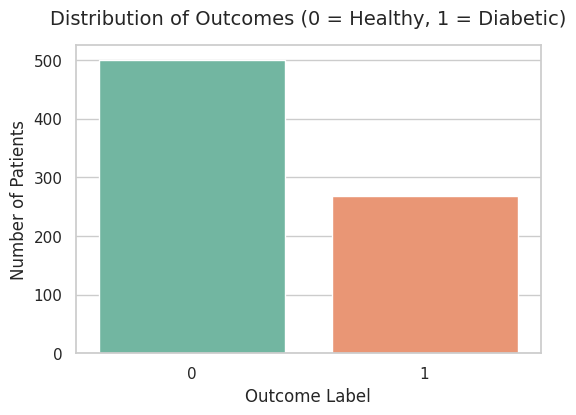

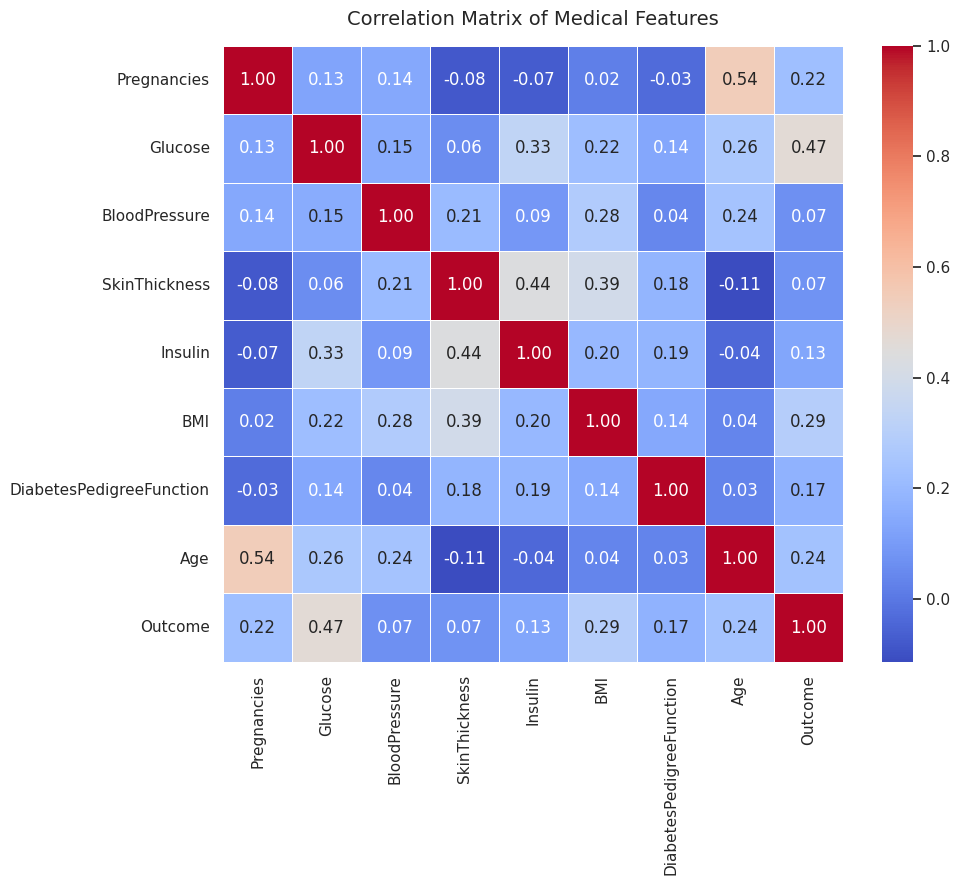

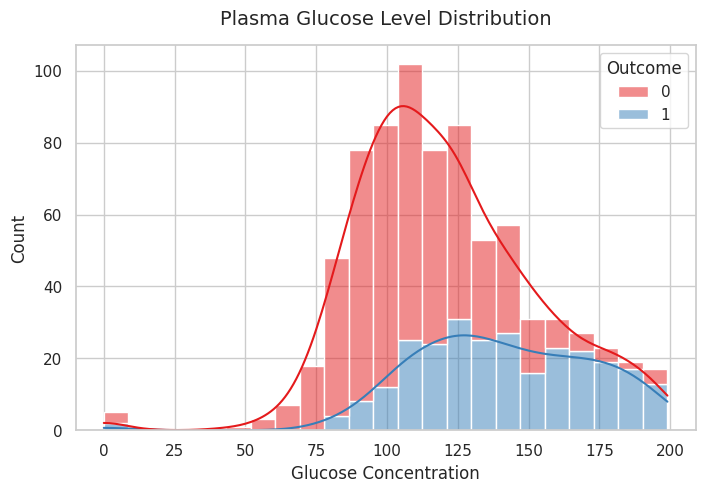

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean grid style for our plots
sns.set_theme(style="whitegrid")

# 1. Chart: Distribution of Diabetic vs Non-Diabetic Patients
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=diabetes_dataset, palette='Set2')
plt.title('Distribution of Outcomes (0 = Healthy, 1 = Diabetic)', fontsize=14, pad=15)
plt.xlabel('Outcome Label', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.show()

# 2. Chart: Feature Correlation Heatmap
# This shows how strongly each medical metric relates to the Outcome
plt.figure(figsize=(10, 8))
sns.heatmap(diabetes_dataset.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Medical Features', fontsize=14, pad=15)
plt.show()

# 3. Chart: Glucose Distribution by Diabetes Outcome
# Since Glucose is a major indicator, this plot shows how the groups separate
plt.figure(figsize=(8, 5))
sns.histplot(data=diabetes_dataset, x='Glucose', hue='Outcome', kde=True, multiple='stack', palette='Set1')
plt.title('Plasma Glucose Level Distribution', fontsize=14, pad=15)
plt.xlabel('Glucose Concentration', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

/tmp/ipykernel_2054/2291628078.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=diabetes_dataset, palette='pastel', ax=ax[0])
/tmp/ipykernel_2054/2291628078.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Healthy (0)', 'Diabetic (1)'])
/tmp/ipykernel_2054/2291628078.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=diabetes_dataset, palette='Set2', ax=ax[1])
/tmp/ipykernel_2054/2291628078.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


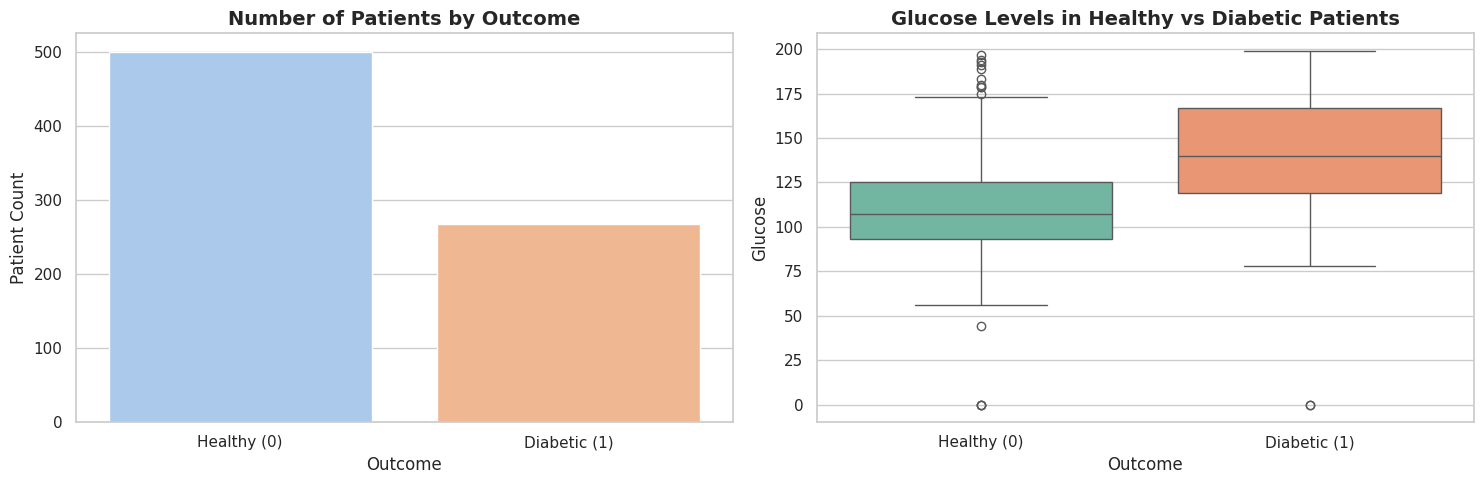

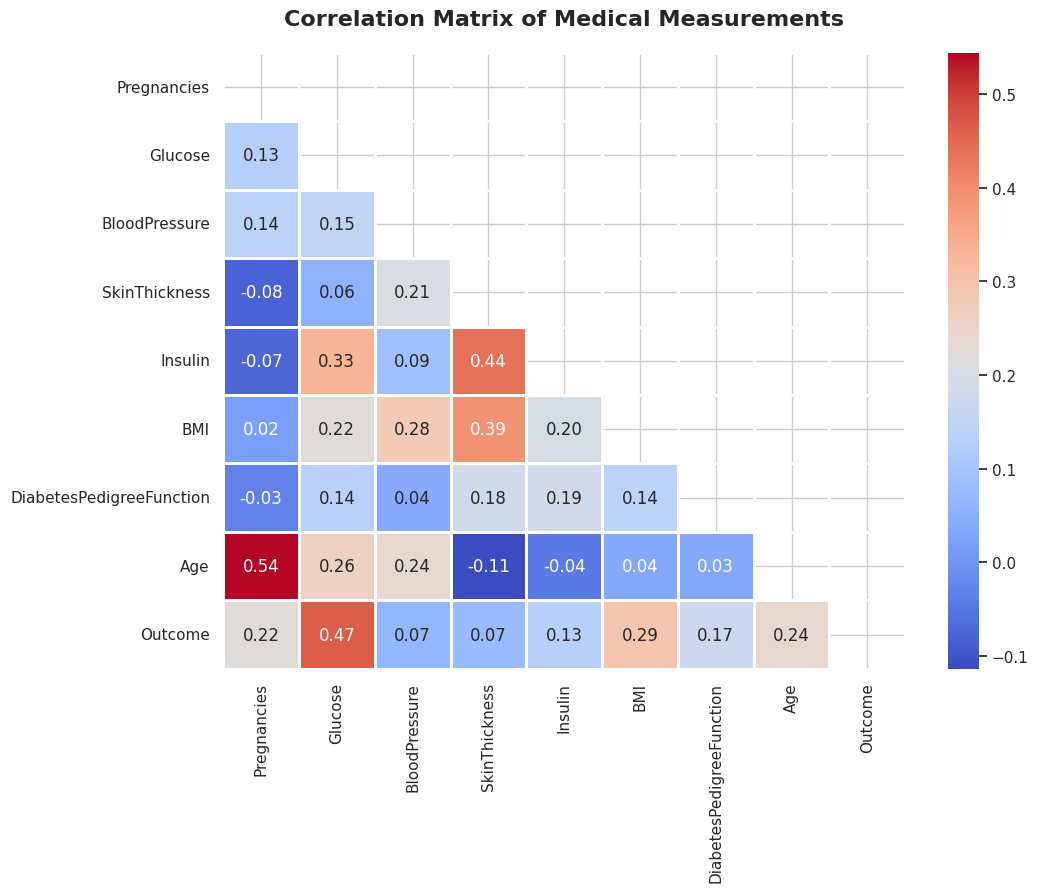

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a premium look and feel
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# 1. Chart: Distribution of Target Class (Balanced vs Imbalanced check)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x='Outcome', data=diabetes_dataset, palette='pastel', ax=ax[0])
ax[0].set_title('Number of Patients by Outcome', fontsize=14, weight='bold')
ax[0].set_xticklabels(['Healthy (0)', 'Diabetic (1)'])
ax[0].set_ylabel('Patient Count')

# 2. Chart: Boxplot to visualize Age vs Glucose distribution
sns.boxplot(x='Outcome', y='Glucose', data=diabetes_dataset, palette='Set2', ax=ax[1])
ax[1].set_title('Glucose Levels in Healthy vs Diabetic Patients', fontsize=14, weight='bold')
ax[1].set_xticklabels(['Healthy (0)', 'Diabetic (1)'])

plt.tight_layout()
plt.show()

# 3. Chart: Complete Feature Correlation Heatmap Matrix
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(diabetes_dataset.corr(), dtype=bool)) # Makes it a clean triangle
sns.heatmap(diabetes_dataset.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Matrix of Medical Measurements', fontsize=16, weight='bold', pad=20)
plt.show()

4. SEPEARTE DATA AND LABELS

In [17]:
# Assign all data to X (features) and the target 'Outcome' to Y
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

5. STANDARDIZE THE DATA

In [18]:
# Initialize scaler
scaler = StandardScaler()

# Fit and transform the data
scaler.fit(X)
X = scaler.transform(X)

6. SPLIT TRAIN AND TEST DATA

In [19]:
# Split data into 80% Training and 20% Testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

7. ACCURACY

In [26]:
# Training data accuracy
X_train_prediction = best_model.predict(X_train)
print('Training accuracy:', accuracy_score(X_train_prediction, Y_train))

# Testing data accuracy
X_test_prediction = best_model.predict(X_test)
print('Testing accuracy:', accuracy_score(X_test_prediction, Y_test))

Training accuracy: 0.7866449511400652
Testing accuracy: 0.7727272727272727


8. MODEL EVOLUTION

🎯 Support Vector Machine Accuracy: 77.27%
🎯 Logistic Regression Accuracy: 75.97%
🎯 Random Forest Accuracy: 72.73%


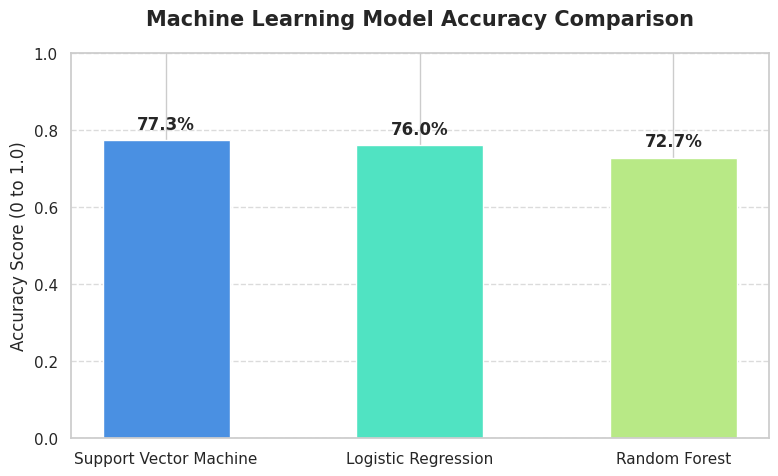

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define the models we want to compare
models = {
    'Support Vector Machine': svm.SVC(kernel='linear'),
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=2)
}

# Dictionary to store accuracy scores
accuracy_results = {}

# Automatically loop, train, and score every model
for name, model in models.items():
    model.fit(X_train, Y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(predictions, Y_test)
    accuracy_results[name] = acc
    print(f"🎯 {name} Accuracy: {acc * 100:.2f}%")

# Generate a gorgeous performance comparison bar graph
plt.figure(figsize=(9, 5))
colors = ['#4A90E2', '#50E3C2', '#B8E986']
bars = plt.bar(accuracy_results.keys(), accuracy_results.values(), color=colors, width=0.5)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval*100:.1f}%", ha='center', va='bottom', weight='bold')

plt.title('Machine Learning Model Accuracy Comparison', fontsize=15, weight='bold', pad=20)
plt.ylabel('Accuracy Score (0 to 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

10. TRAINING THE MODEL

In [28]:
# Initialize and train the Support Vector Machine
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

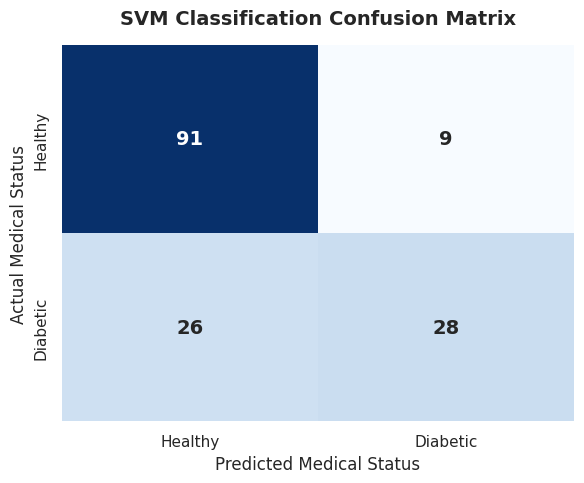

In [21]:
from sklearn.metrics import confusion_matrix

# Let's inspect the active SVM model's predictions deeper
best_model = models['Support Vector Machine']
Y_pred = best_model.predict(X_test)
cm = confusion_matrix(Y_test, Y_pred)

# Build a visually stunning confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy', 'Diabetic'],
            yticklabels=['Healthy', 'Diabetic'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('SVM Classification Confusion Matrix', fontsize=14, weight='bold', pad=15)
plt.ylabel('Actual Medical Status', fontsize=12)
plt.xlabel('Predicted Medical Status', fontsize=12)
plt.tight_layout()
plt.show()

9. PERFORMANCE EVALUATION

In [22]:
# Insert metrics for a custom patient observation check
# Format: (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age)
sample_patient_metrics = (5, 166, 72, 19, 175, 25.8, 0.587, 51)

# Formatting logic
input_data_as_numpy_array = np.asarray(sample_patient_metrics).reshape(1, -1)
std_data = scaler.transform(input_data_as_numpy_array)

# Use our trained SVM model to make the prediction
final_prediction = best_model.predict(std_data)

print("="*50)
print("       🏥 MEDICAL DIAGNOSTIC REPORT SYSTEM       ")
print("="*50)
print(f"Patient Attributes Evaluated: {sample_patient_metrics}")
print("-"*50)

if final_prediction[0] == 0:
    print("🚨 RESULT: STATUS NORMAL (The patient is NOT diabetic) ✅")
else:
    print("🚨 RESULT: HIGH RISK DETECTED (The patient IS diabetic) ⚠️")
print("="*50)

       🏥 MEDICAL DIAGNOSTIC REPORT SYSTEM       
Patient Attributes Evaluated: (5, 166, 72, 19, 175, 25.8, 0.587, 51)
--------------------------------------------------
🚨 RESULT: HIGH RISK DETECTED (The patient IS diabetic) ⚠️


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


10.  INTERACTIVE DIAGNOSTIC APP

In [30]:
import ipywidgets as widgets
from IPython.display import display

# Create input widgets for each feature
pregnancies = widgets.IntSlider(value=1, min=0, max=20, step=1, description='Pregnancies:')
glucose = widgets.FloatSlider(value=120, min=0, max=200, step=1, description='Glucose:')
bp = widgets.FloatSlider(value=70, min=0, max=150, step=1, description='Blood Pressure:')
skin = widgets.FloatSlider(value=20, min=0, max=100, step=1, description='Skin Thickness:')
insulin = widgets.FloatSlider(value=80, min=0, max=900, step=1, description='Insulin:')
bmi = widgets.FloatSlider(value=25, min=0, max=70, step=0.1, description='BMI:')
dpf = widgets.FloatSlider(value=0.5, min=0, max=2.5, step=0.01, description='Diabetes Pedigree:')
age = widgets.IntSlider(value=30, min=18, max=100, step=1, description='Age:')

# Button to trigger prediction
button = widgets.Button(description="Predict Health Status", button_style='success', icon='check')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        # Get values from widgets
        input_data = (pregnancies.value, glucose.value, bp.value, skin.value,
                      insulin.value, bmi.value, dpf.value, age.value)

        # Standardize and predict
        data_as_numpy = np.asarray(input_data).reshape(1, -1)
        std_data = scaler.transform(data_as_numpy)
        prediction = best_model.predict(std_data)

        print("\n--- Diagnostic Results ---")
        if prediction[0] == 0:
            print("✅ RESULT: Status Normal (Not Diabetic)")
        else:
            print("⚠️ RESULT: High Risk Detected (Diabetic)")

button.on_click(on_button_clicked)
display(pregnancies, glucose, bp, skin, insulin, bmi, dpf, age, button, output)

IntSlider(value=1, description='Pregnancies:', max=20)

FloatSlider(value=120.0, description='Glucose:', max=200.0, step=1.0)

FloatSlider(value=70.0, description='Blood Pressure:', max=150.0, step=1.0)

FloatSlider(value=20.0, description='Skin Thickness:', step=1.0)

FloatSlider(value=80.0, description='Insulin:', max=900.0, step=1.0)

FloatSlider(value=25.0, description='BMI:', max=70.0)

FloatSlider(value=0.5, description='Diabetes Pedigree:', max=2.5, step=0.01)

IntSlider(value=30, description='Age:', min=18)

Button(button_style='success', description='Predict Health Status', icon='check', style=ButtonStyle())

Output()

11. MODEL DEPLOYMENT

In [31]:
import joblib

# Save the trained model and the scaler to files
joblib.dump(best_model, 'diabetes_svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("🏆 Success! Model and Scaler have been saved for deployment.")

🏆 Success! Model and Scaler have been saved for deployment.
